In [1]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

2026-04-12 16:36:27.380536: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776011787.614960     142 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776011787.683424     142 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776011788.217266     142 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776011788.217311     142 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776011788.217314     142 computation_placer.cc:177] computation placer alr

In [2]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [3]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [4]:
tr_df = train_df('/kaggle/input/datasets/jaskiratsinghchopra/brain-tumor-mri-dataset/Training')

In [5]:
tr_df

,Class Path,Class
0,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
1,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
2,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
3,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
4,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
...,...,...
5595,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma
5596,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma
5597,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma
5598,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma


In [6]:
ts_df = test_df('/kaggle/input/datasets/jaskiratsinghchopra/brain-tumor-mri-dataset/Testing')

In [7]:
ts_df 

,Class Path,Class
0,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
1,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
2,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
3,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
4,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
...,...,...
1595,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma
1596,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma
1597,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma
1598,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma


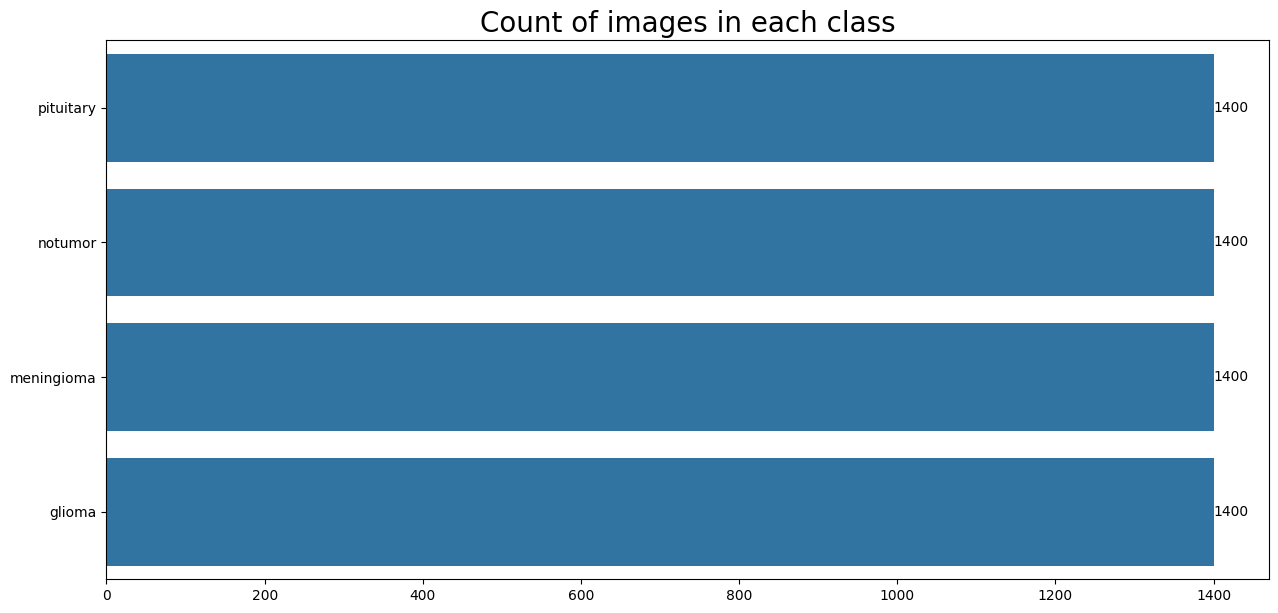

In [8]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

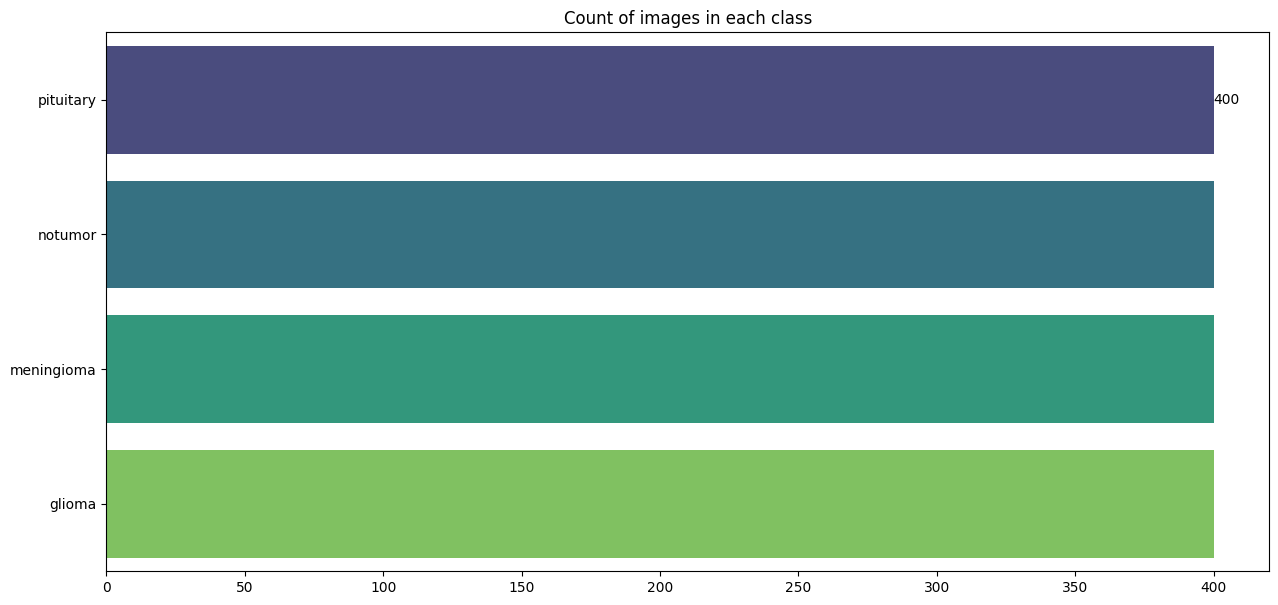

In [9]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

In [10]:
import os

def count_images_in_directory(base_path):
    """
    Counts total number of images and per-class counts inside each subfolder.
    """
    total_images = 0
    class_counts = {}

    for class_name in os.listdir(base_path):
        class_folder = os.path.join(base_path, class_name)
        if os.path.isdir(class_folder):
            count = len([
                img for img in os.listdir(class_folder)
                if img.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp'))
            ])
            class_counts[class_name] = count
            total_images += count

    return total_images, class_counts


# Paths (update these if needed)
train_path = '/kaggle/input/datasets/jaskiratsinghchopra/brain-tumor-mri-dataset/Training'
test_path = '/kaggle/input/datasets/jaskiratsinghchopra/brain-tumor-mri-dataset/Testing'

# Count training and testing images
train_total, train_classes = count_images_in_directory(train_path)
test_total, test_classes = count_images_in_directory(test_path)

print("=== Training Set ===")
for cls, count in train_classes.items():
    print(f"{cls:15}: {count} images")
print(f"Total Training Images: {train_total}\n")

print("=== Testing Set ===")
for cls, count in test_classes.items():
    print(f"{cls:15}: {count} images")
print(f"Total Testing Images: {test_total}")


=== Training Set ===
pituitary      : 1400 images
notumor        : 1400 images
meningioma     : 1400 images
glioma         : 1400 images
Total Training Images: 5600

=== Testing Set ===
pituitary      : 400 images
notumor        : 400 images
meningioma     : 400 images
glioma         : 400 images
Total Testing Images: 1600


In [11]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])
valid_df

,Class Path,Class
198,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
857,/kaggle/input/datasets/jaskiratsinghchopra/bra...,meningioma
1098,/kaggle/input/datasets/jaskiratsinghchopra/bra...,meningioma
1119,/kaggle/input/datasets/jaskiratsinghchopra/bra...,meningioma
508,/kaggle/input/datasets/jaskiratsinghchopra/bra...,notumor
...,...,...
1281,/kaggle/input/datasets/jaskiratsinghchopra/bra...,glioma
172,/kaggle/input/datasets/jaskiratsinghchopra/bra...,pituitary
792,/kaggle/input/datasets/jaskiratsinghchopra/bra...,notumor
933,/kaggle/input/datasets/jaskiratsinghchopra/bra...,meningioma


Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


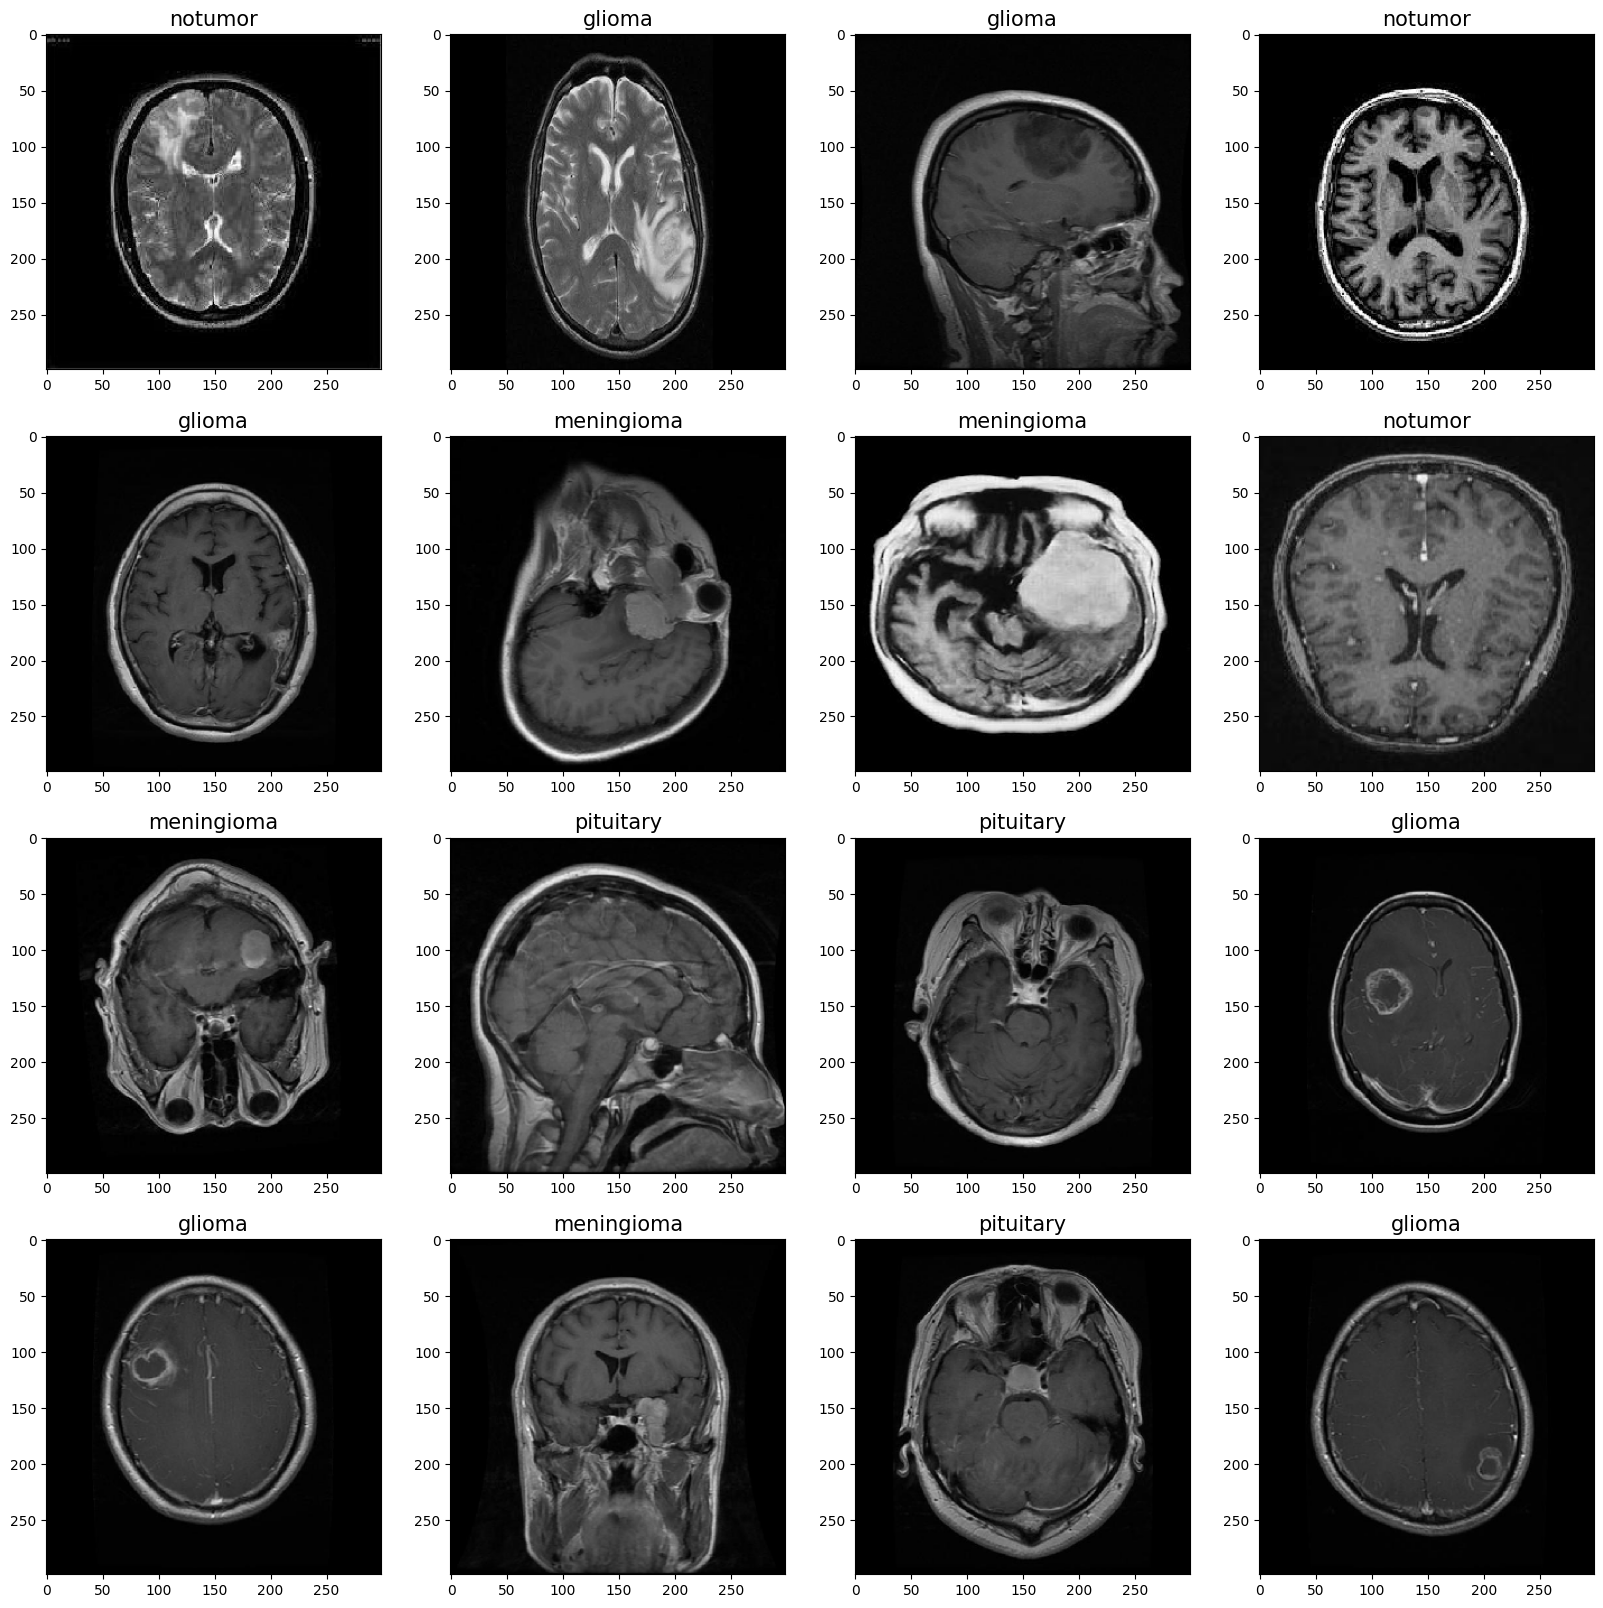

In [12]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

In [13]:
img_shape=(299,299,3)
base_model = tf.keras.applications.EfficientNetB3(include_top=False, weights='imagenet',
                            input_shape=img_shape, pooling='max')

# for layer in base_model.layers:
#     layer.trainable = False
    
model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

I0000 00:00:1776011843.870732     142 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776011843.876849     142 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,980,787 (41.89 MB)

 Trainable params: 10,893,484 (41.56 MB)

 Non-trainable params: 87,303 (341.03 KB)

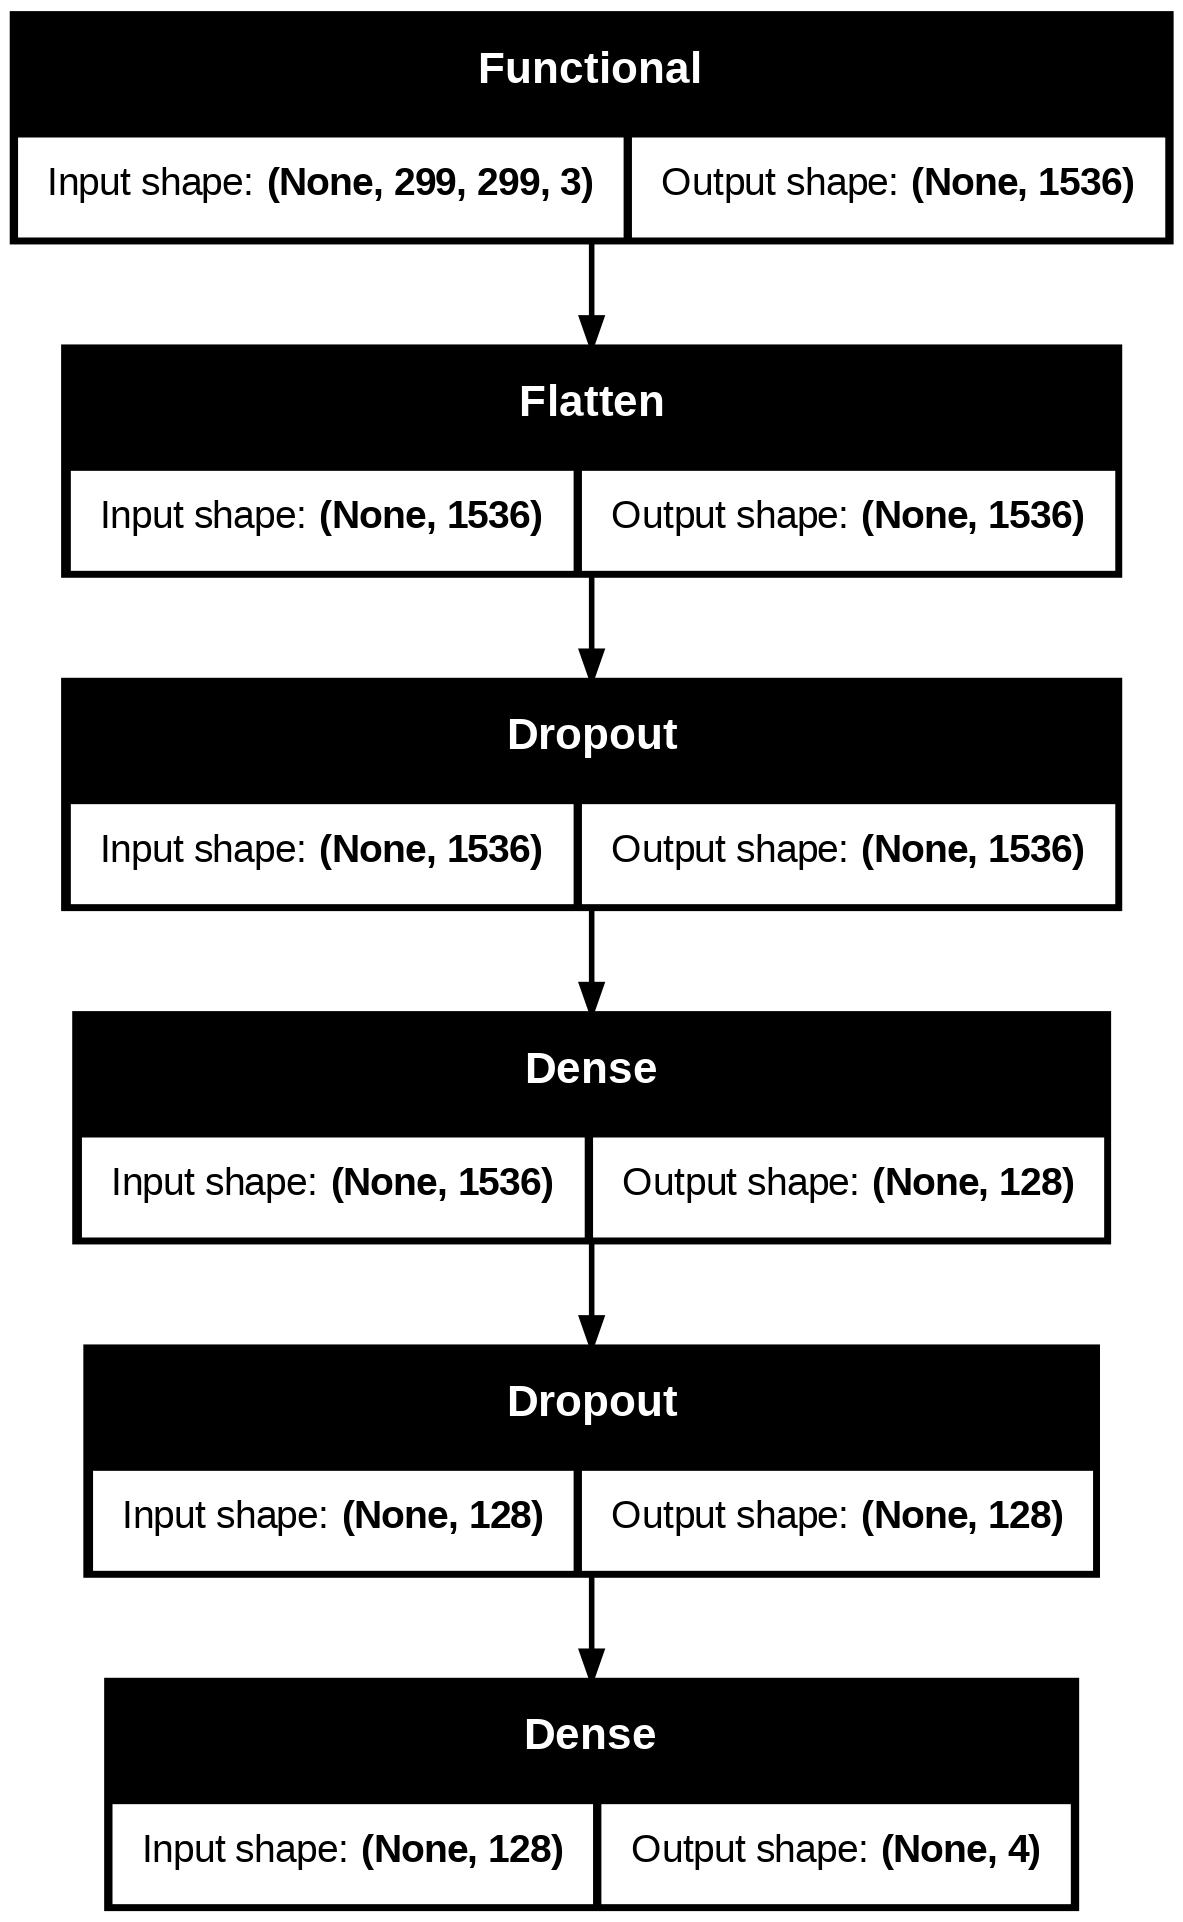

In [14]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [15]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# ── 1. DO NOT use mixed_float16 with EfficientNet ─────────────────────────────
# Remove mixed_precision entirely for EfficientNet

# ── 2. Rebuild data generators WITHOUT rescale=1/255 ─────────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (300, 300)   # EfficientNetB3 native size
batch_size = 32

_gen    = ImageDataGenerator(brightness_range=(0.8, 1.2))  # NO rescale
ts_gen_ = ImageDataGenerator()                              # NO rescale

tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen_.flow_from_dataframe(ts_df, x_col='Class Path',
                                     y_col='Class', batch_size=16,
                                     target_size=img_size, shuffle=False)

# ── 3. Build EfficientNetB3 model ─────────────────────────────────────────────
img_shape = (300, 300, 3)
base_model = tf.keras.applications.EfficientNetB3(include_top=False,
                                                   weights='imagenet',
                                                   input_shape=img_shape,
                                                   pooling='max')

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate=0.3),
    Dense(128, activation='relu'),
    Dropout(rate=0.25),
    Dense(4, activation='softmax')
])

model.compile(Adamax(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall')])

# ── 4. Callbacks ──────────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

# ── 5. Train ──────────────────────────────────────────────────────────────────
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 callbacks=callbacks,
                 shuffle=False)


Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Epoch 1/10


I0000 00:00:1776011880.265280     207 service.cc:152] XLA service 0x7ec14441e9d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776011880.265319     207 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776011880.265323     207 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776011883.898214     207 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-12 16:38:16.548496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 16:38:16.706049: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 16:38:17.158232: E external/local_xl

175/175 ━━━━━━━━━━━━━━━━━━━━ 121s 413ms/step - accuracy: 0.4684 - loss: 2.8089 - precision: 0.4920 - recall: 0.4185 - val_accuracy: 0.7100 - val_loss: 0.7698 - val_precision: 0.8206 - val_recall: 0.4975 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 212ms/step - accuracy: 0.6356 - loss: 0.8737 - precision: 0.7122 - recall: 0.5271 - val_accuracy: 0.7575 - val_loss: 0.6464 - val_precision: 0.8418 - val_recall: 0.6650 - learning_rate: 0.0010
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 213ms/step - accuracy: 0.7146 - loss: 0.7147 - precision: 0.7665 - recall: 0.6442 - val_accuracy: 0.7912 - val_loss: 0.5768 - val_precision: 0.8550 - val_recall: 0.7150 - learning_rate: 0.0010
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 35s 201ms/step - accuracy: 0.7284 - loss: 0.6652 - precision: 0.7795 - recall: 0.6716 - val_accuracy: 0.7800 - val_loss: 0.5405 - val_precision: 0.8405 - val_recall: 0.7312 - learning_rate: 0.0010
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 35s 201ms/step - accur

In [16]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])

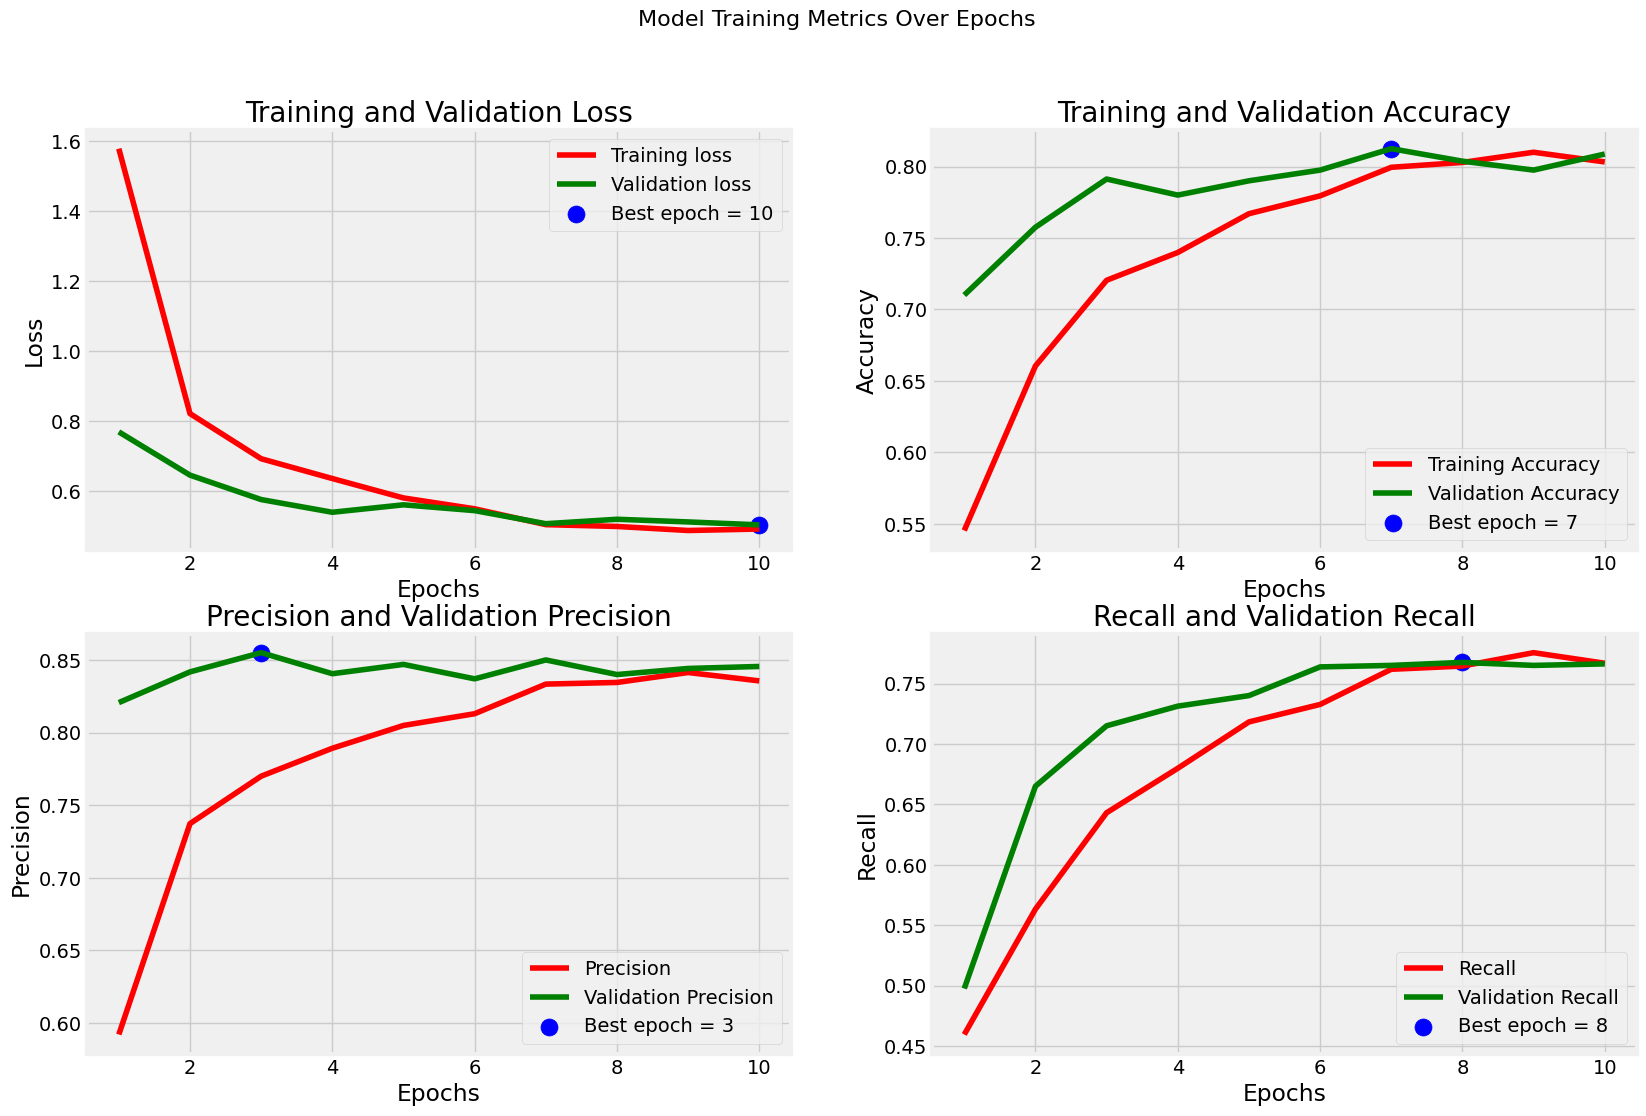

In [20]:
tr_acc    = hist.history['accuracy']
tr_loss   = hist.history['loss']
tr_per    = hist.history['precision']
tr_recall = hist.history['recall']
val_acc    = hist.history['val_accuracy']
val_loss   = hist.history['val_loss']
val_per    = hist.history['val_precision']
val_recall = hist.history['val_recall']

# ── These must be in the SAME cell as above ───────────────────────────────────
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'

plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')

plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()


In [21]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 204ms/step - accuracy: 0.8835 - loss: 0.3178 - precision: 0.9013 - recall: 0.8599
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.8111 - loss: 0.4712 - precision: 0.8496 - recall: 0.7727


2026-04-12 17:00:16.460372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:00:16.606163: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:00:16.965387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:00:17.112314: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:00:17.935177: E external/local_xla/xla/stream_

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.7900 - loss: 0.5284 - precision: 0.8292 - recall: 0.7497
Train Loss: 0.3115
Train Accuracy: 88.75%
--------------------
Validation Loss: 0.5056
Validation Accuracy: 80.75%
--------------------
Test Loss: 0.5090
Test Accuracy: 80.50%
